In [23]:
import os
if os.path.basename(os.getcwd()) == 'Demonstrations':
    os.chdir('..')

<div style="background-color: #bee7ff; color: white; padding: 30px; border-radius: 0px;">
<h1 style="margin: 0;  color: #1e1a66">Attention Mechanism</h1>
<h3 style="margin: 0;  color: #1e1a66">Multi-Head Attention</h3>
</div>

Imports:

In [32]:
import numpy as np

from Utilities.Exchanger_Device import compute_U_P_solution_exchanger_device

from Utilities.Stokes_felib import (
    evalOnTrigs
)

from Utilities.Mesh_processing import (
    refine
)

from Utilities.Plot_functions import (
    Plot_Initial_Refined_meshes,
    plot_viscosity,
    Plot_Velocity_and_Pressure,
)

---

We begin with loading and storing data in the raw data matrix $\mathbf{X} \in \mathbb{R}^{2N_v \times (3+4k)}$, the $i^{th}$ row is defined as follows:

$$x_i^{\text{raw}} = \begin{bmatrix} x_i \\ y_i \\ \mu_1 \\ \vdots \\ \mu_k \\ p^{x}_{i,1} \\ \vdots \\ p^{x}_{i,1} \\ p^{y}_{i,1} \\ \vdots \\ p^{y}_{i,1} \\ \hat{w}_{i,1} \\ \vdots \\ \hat{w}_{i,k} \\ b \end{bmatrix} \in \mathbb{R}^{3+4k}$$

where:

* $(x_i, y_i)$ are the spatial coordinates of node $i$, denoted as $x_i \in \Omega$.


* $\boldsymbol{\mu} = [\mu_1, \dots, \mu_p]^\top$ are the prescribed global viscosity parameters at the $p$ control points.


* $(p^x_m, p^y_m)$ are the spatial coordinates of the $m$-th control point $x_m$ for $m \in \{1, \dots, p\}$.


* $\psi_m(x_i) = \frac{w_m(x_i)}{\sum_{j=1}^p w_j(x_i)}$ is the normalized Shepard basis function for control point $m$ evaluated at node $x_i$.


* $w_m(x_i) = \frac{1}{\max(d_m, \epsilon)^\gamma}$ is the inverse-distance weight, where $d_m = \vert{}x_i - x_m\vert{}_2$ is the Euclidean distance from node $x_i$ to control point $x_m$, $\epsilon$ is the softening parameter, and $\gamma$ is the decay power.


* $b_i$ is the boundary condition flag for node $i$ extracted from the mesh geometry.

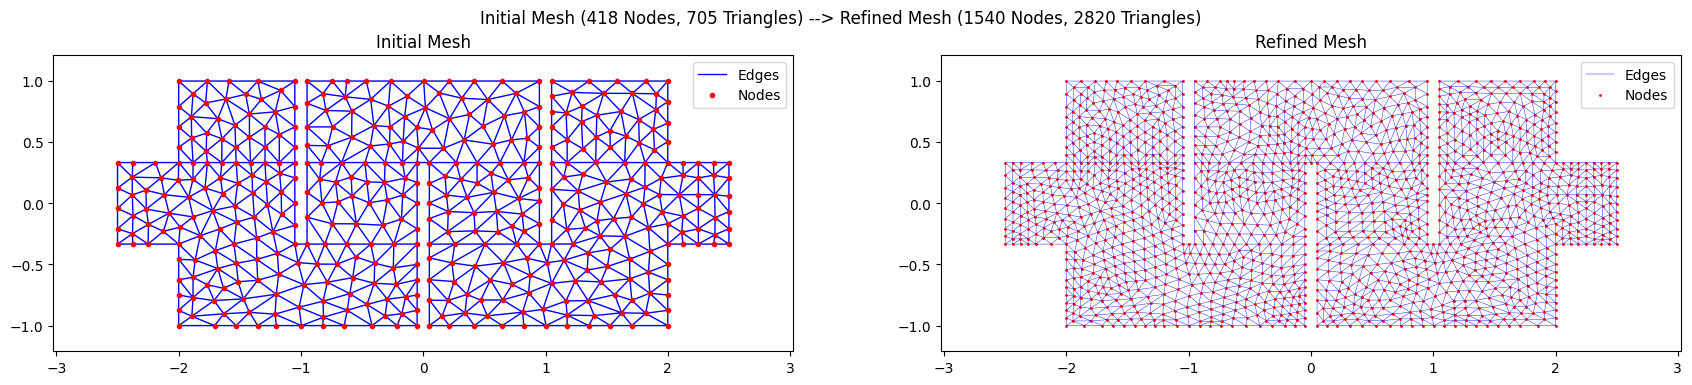

In [25]:
p_coarse, e_coarse, t_coarse = Plot_Initial_Refined_meshes(
    data_path='Meshes/exchanger_device_altered_mesh_data.npz',
    num_of_refinements=1,
    figsize=(21, 4),
    plot=True, name=''
)
p_fine, e_fine, t_fine = refine(p_coarse, e_coarse, t_coarse)

In [53]:
def viscosity_field(p, param_vec, loc, power: float = 2.0, eps: float = 1e-12):
        """
        Inverse-distance weighted viscosity at every node in p (N, 2).
        power=2  is the standard Shepard interpolation.
        Increase power (e.g. 4-6) for sharper, more localised influence zones.
        """
        diff = p[:, None, :] - loc[None, :, :]
        d    = np.linalg.norm(diff, ord=2, axis=2)   

        exact = d < eps
        hit   = exact.any(axis=1)

        w  = 1.0 / np.where(d < eps, eps, d) ** power
        w /= w.sum(axis=1, keepdims=True)
        nu = (w * param_vec[None, :]).sum(axis=1) 

        if hit.any():
            knot_idx = np.argmax(exact[hit], axis=1)
            nu[hit]  = param_vec[knot_idx]

        return nu, w

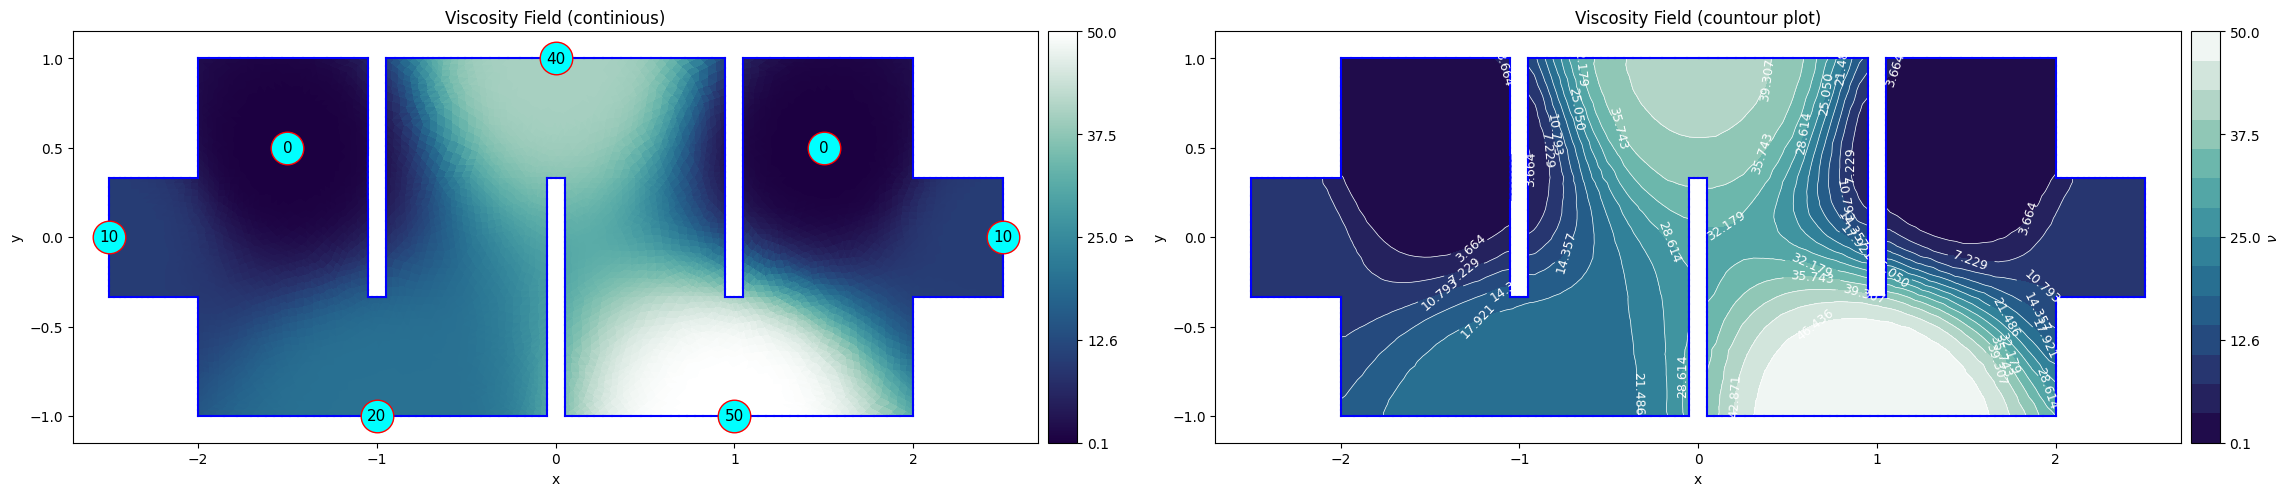

In [68]:
alpha = 1
parameter_loc = np.array([
      [-2.5,  0.0],
      [-1.5,  alpha/2],
      [-1.0, -alpha],
      [ 0.0,  alpha],
      [ 1.0, -alpha],
      [ 1.5,  alpha/2],
      [ 2.5,  0.0],
      ])
mu = np.array([10, 0.1, 20, 40, 50, 0.1, 10])

centroids = p_fine[t_fine[:, :3]].mean(axis=1)
nu_field_elem, _ = viscosity_field(centroids, mu, parameter_loc, power=4.0)
_, w_raw_nodes = viscosity_field(p_fine, mu, parameter_loc, power=4.0)

nu_dict = {
        "pts":  parameter_loc,
        "vals": mu
    }

plot_viscosity(p_fine, t_fine, e_fine, nu_field_elem, nu_dict, 
               n_levels=15, figsize=(23, 10), 
               name=f'{mu}', savetype="png")

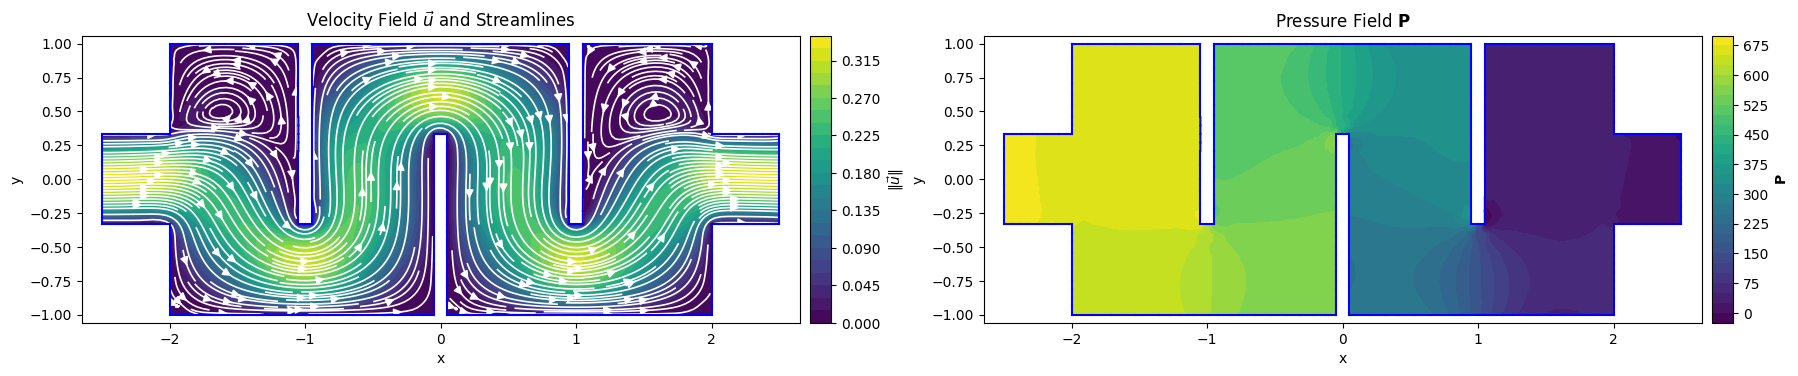

In [69]:
ux, uy, p_sol = compute_U_P_solution_exchanger_device(p_fine, t_fine, e_fine, p_coarse, t_coarse, kinematic_viscosity=nu_field_elem)
Plot_Velocity_and_Pressure(p_fine, t_fine, p_coarse, t_coarse, e_coarse, ux, uy, p_sol, name='')

---

Then we can commence with the token matrix $\mathbf{E} \in \mathbb{R}^{N \times d}$